# O25 Practical Code
Second attempt

# Practical 1 - Computing the Kaplan-Yorke Dimension

## Problem definition + Simulation
The Quasi-Static Spring Slider

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from tqdm import tqdm

## CONSTANTS

beta_1 = 1
beta_2 = 0.84
rho = 0.048

kappa_prime = 0.8544
kappa_cr_1 = beta_1 - 1
kappa_cr_2 = (
    kappa_cr_1 + rho*(2*beta_1 + (beta_2-1)*(2+rho)) + np.sqrt(
        4*rho**2 * (kappa_cr_1+beta_2) + (kappa_cr_1 + rho**2 * (beta_2-1))**2
    )
) / (2*(1+rho))

kappa = kappa_cr_2 * kappa_prime
v_0 = 1

## EOMS

def backup_func(t, input_vars):
    x, y, z = input_vars

    return (
        (-kappa * (np.exp(x) - v_0) + np.exp(x) * (
            x*(beta_1-1) + y - z
        ) + rho * np.exp(x) * (beta_2*x + z)),
        -kappa * (np.exp(x)-v_0),
        -rho*np.exp(x)*(
            beta_2*x+z
        )
    )

## alternate jacobian from lectures potentially instead?
#from scipy.differentiate import jacobian

## manual implementation
def jacobian(input_vars, kappa=kappa, beta_1=beta_1, beta_2=beta_2, rho=rho):

    assert len(input_vars) == 3

    x, y, z = input_vars

    ex = np.exp(x)

    J11 = -kappa * ex + ex * (
        x*(beta_1 - 1) + y - z + beta_1 - 1
    ) + rho * ex * (beta_2 * x + z + beta_2)
    J12 = ex
    J13 = ex * (-1 + rho)

    J21 = -kappa * ex
    J22 = 0
    J23 = 0

    J31 = -rho * ex * beta_2 * (x + 1)
    J32 = 0
    J33 = -rho * ex


    jac = np.array([
        [J11, J12, J13],
        [J21, J22, J23],
        [J31, J32, J33]
    ])

    return jac

0.06858744329064924


### Part 1: Numerical Simulation

In [54]:
t_start = 0
t_transient=4000
t_end = 20000
dt = 0.1

t_eval = np.arange(t_transient, t_end, dt)
X_0 = [0.05, 0, 0]

soln = solve_ivp(backup_func, (t_start, t_end), X_0, t_eval=t_eval)

C:\Users\nookh\AppData\Local\Temp\ipykernel_4248\946241783.py:45: RuntimeWarning: overflow encountered in exp
  (-kappa * (np.exp(x) - v_0) + np.exp(x) * (
C:\Users\nookh\AppData\Local\Temp\ipykernel_4248\946241783.py:47: RuntimeWarning: overflow encountered in exp
  ) + rho * np.exp(x) * (beta_2*x + z)),
C:\Users\nookh\AppData\Local\Temp\ipykernel_4248\946241783.py:45: RuntimeWarning: invalid value encountered in scalar add
  (-kappa * (np.exp(x) - v_0) + np.exp(x) * (
C:\Users\nookh\AppData\Local\Temp\ipykernel_4248\946241783.py:48: RuntimeWarning: overflow encountered in exp
  -kappa * (np.exp(x)-v_0),
C:\Users\nookh\AppData\Local\Temp\ipykernel_4248\946241783.py:49: RuntimeWarning: overflow encountered in exp
  -rho*np.exp(x)*(


Text(0.5, 0.98, 'Numerical Simulation of the Quasi-Static Spring Slider')

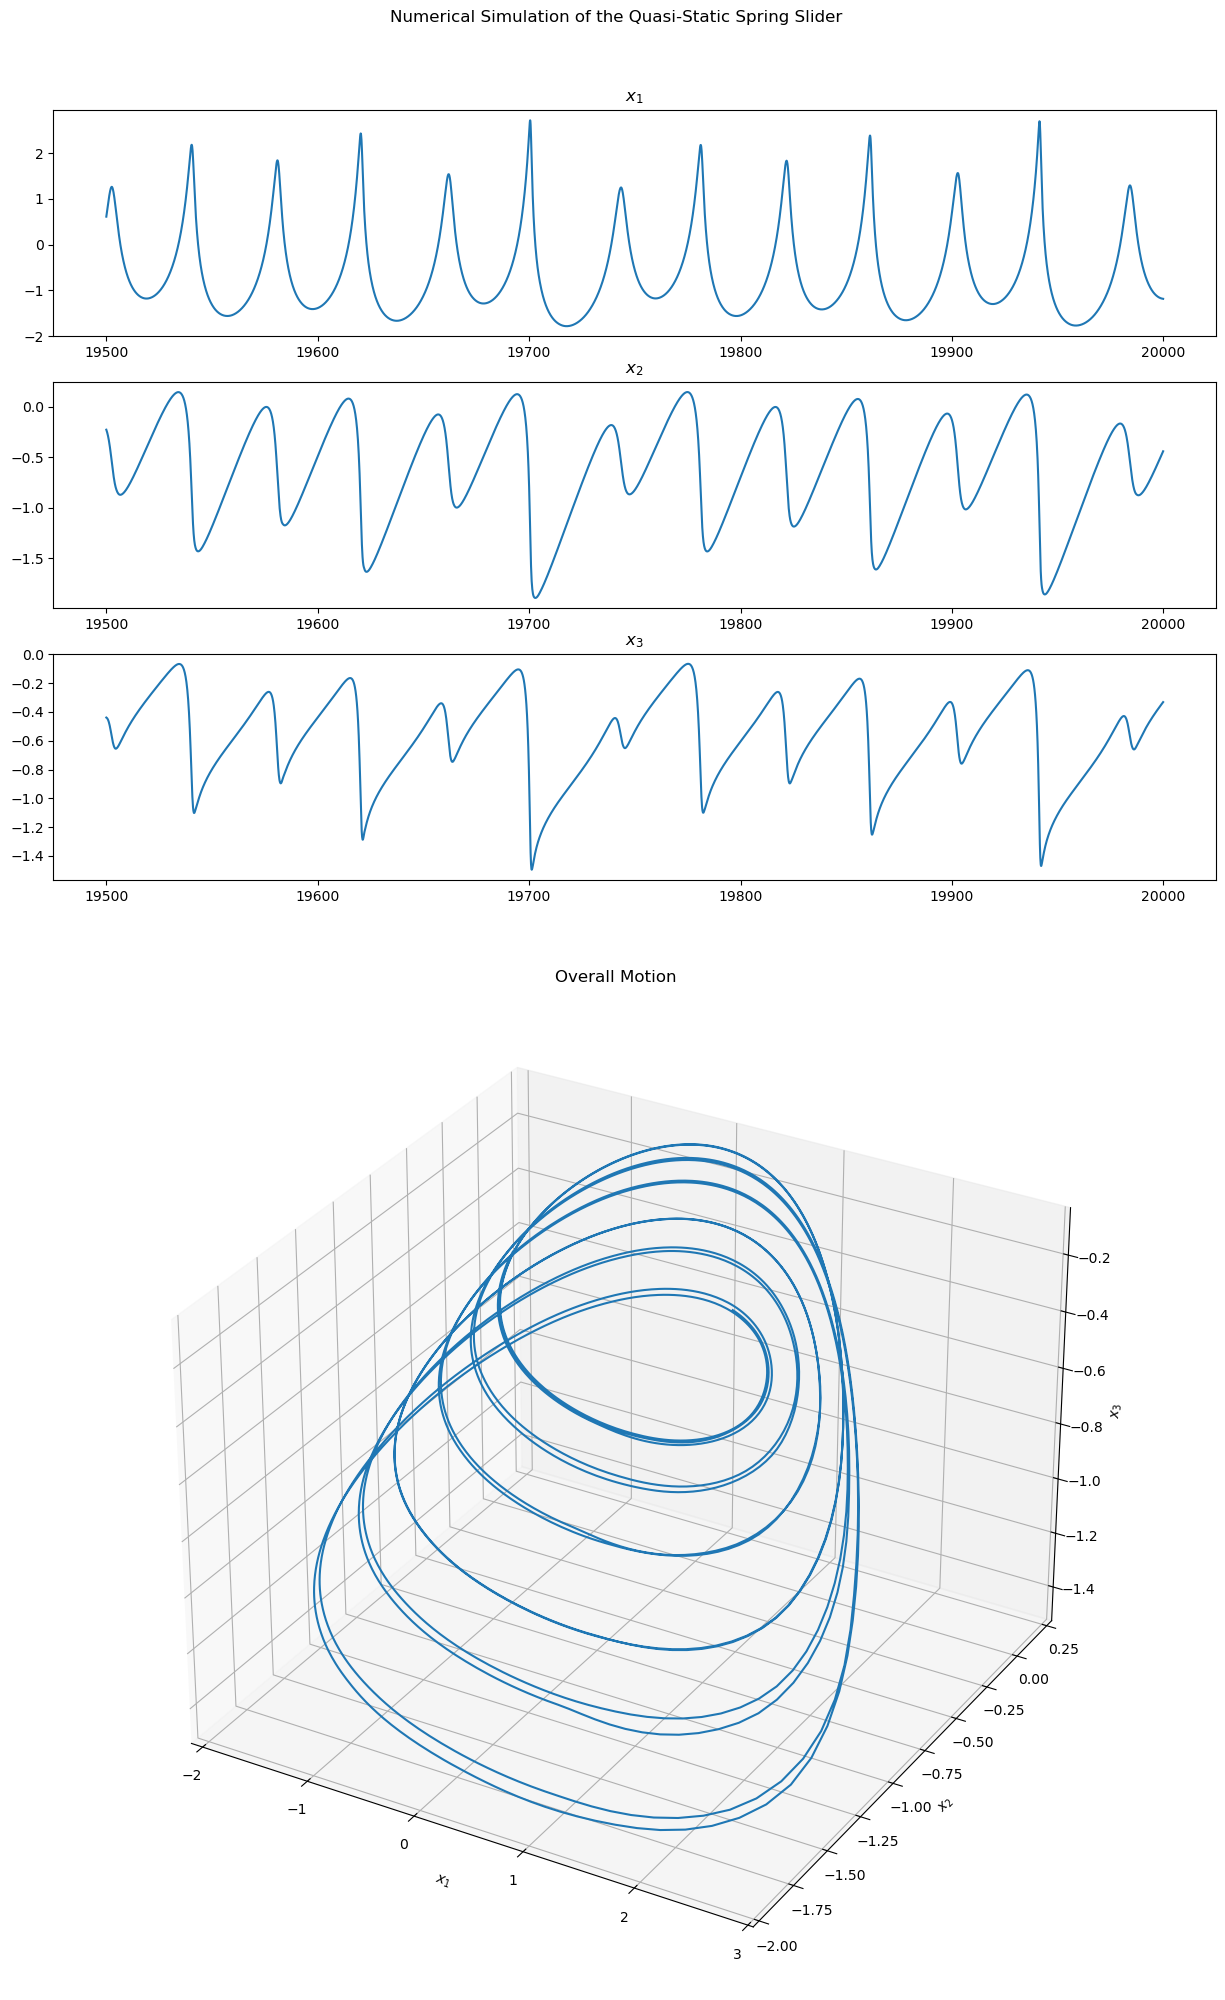

In [72]:
n_points = 5000

t = soln.t[-n_points:]
x, y, z = soln.y[:,-n_points:]

fig, ax = plt.subplots(3, 1, figsize=(15, 10))
ax = ax.flatten()

ax[0].plot(t, x)
ax[0].set_title('$x_1$')
ax[1].plot(t, y)
ax[1].set_title('$x_2$')
ax[2].plot(t, z)
ax[2].set_title('$x_3$')

ax_3d = fig.add_axes((0, -1, 1, 1), projection='3d')
ax_3d.plot(x, y, z)

ax_3d.set_xlabel('$x_1$')
ax_3d.set_ylabel('$x_2$')
ax_3d.set_zlabel('$x_3$')

ax_3d.set_title('Overall Motion')

fig.suptitle('Numerical Simulation of the Quasi-Static Spring Slider')

### Part 2: Calculating the Lyapunov Exponents

We need to evolve the basis vectors then perform QR renormalisation at each step, collecting the logarithm of the absolute values of the diagonals of R at each step

In [89]:
def extended_func(t, input_vars):

    assert len(input_vars) == 12 # 3 input vars (x1, x2, x3) + 9 basis vars (3x3 matrix representing 3 basis vectors) 

    X = input_vars[:3]
    flat_basis = input_vars[3:]

    basis = flat_basis.reshape(3, 3)

    dXdt = backup_func(t, X)
    J = jacobian(X)

    new_basis = J @ basis

    return np.concatenate([dXdt, new_basis.flatten()])

In [115]:
from scipy.integrate import solve_ivp

t_start = 0
t_transient=4000
t_end = 10000
dt = 0.1

t_eval = np.arange(t_transient, t_end, dt)
X_0 = [0.05, 0, 0]
initial_basis = np.eye(3)

intial_vars = np.concatenate([X_0, initial_basis.flatten()])

lyap_history = []
cur_vars = intial_vars

lyap_total = np.zeros(3)

for cur_time in tqdm(np.arange(t_start, t_end, dt)):

    soln = solve_ivp(extended_func, (cur_time, cur_time+dt), cur_vars, method='RK45', rtol=1e-8, atol=1e-10)

    cur_vars = soln.y[:,-1]

    ## lyapunov collecting step
    cur_basis = cur_vars[3:].reshape(3, 3)

    Q, R = np.linalg.qr(cur_basis)

    ## the r_ii values (the amount the bases stretch by)
    stretch = np.diag(R)

    ## collect Lyapunov exponents after the transient
    if cur_time >= t_transient:

        lyap_total += np.log(np.abs(stretch))

        lyap_exponents = np.log(np.abs(stretch)) / cur_time

        lyap_history.append(lyap_exponents)

    ## set the basis vectors to the orthogonal ones
    cur_vars[3:] = Q.flatten()        

  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [02:57<00:00, 562.23it/s]


In [122]:
lyap_total / t_end

array([ 0.05817479,  0.01631861, -0.120059  ])

In [117]:
b = [[float(j) for j in list(i)] for i in lyap_history]

with open('exponents.txt', 'w') as outfile:
    outfile.write(repr(b))

In [120]:
import matplotlib.pyplot as plt

a = np.array(lyap_history).T
final_le = a.sum(axis=1)

2+final_le[0]+final_le[1] / abs(final_le[2])

np.float64(2.2243468377053213)